# 08 — Propulsion Integration

Complete workflow for integrating the EDF propulsion duct into the BWB fuselage:
1. Duct placement & configuration summary
2. Body envelope & automated clearance validation
3. Longitudinal XZ integration view
4. Cross-section evolution & transverse cuts
5. Duct aerodynamic performance
6. CAD export (STL + STEP with boolean cuts)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D

from src.parameterization.design_variables import params_from_vector
from src.parameterization.bwb_aircraft import build_body_airfoil
from src.propulsion import (
    EDF_70MM,
    compute_duct_placement, compute_duct_centerline,
    duct_cross_section, validate_duct_clearance,
    build_intake_geometry, build_sduct_geometry,
    build_edf_housing, build_exhaust_geometry,
    compute_duct_aero, print_duct_aero_summary,
)

# Load optimized design
best_x = np.load('../output/best_x.npy')
params = params_from_vector(best_x)
placement = compute_duct_placement(params, EDF_70MM)
bc = placement.body_chord

print(f'Body root chord:     {bc*1000:.1f} mm')
print(f'Body t/c:            {params.body_tc_root:.1%}')
print(f'Available height:    {params.body_tc_root * bc * 1000:.1f} mm')
print(f'EDF duct OD:         {placement.duct_od*1000:.1f} mm')
print()
print(f'Intake:   x/c={placement.intake_x_frac:.0%}  z={placement.intake_z*1000:+.1f}mm  '
      f'{placement.intake_width*1000:.0f}x{placement.intake_depth*1000:.0f}mm (WxD)')
print(f'Fan:      x/c={placement.fan_x_frac:.0%}  z={placement.fan_z*1000:+.1f}mm  '
      f'dia={placement.fan_diameter*1000:.0f}mm')
print(f'Exhaust:  x/c={placement.exhaust_x_frac:.0%}  z={placement.exhaust_z*1000:+.1f}mm  '
      f'{placement.exhaust_width*1000:.1f}x{placement.exhaust_height*1000:.1f}mm slot')

Body root chord:     700.3 mm
Body t/c:            21.6%
Available height:    151.4 mm
EDF duct OD:         78.0 mm

Intake:   x/c=8%  z=+85.9mm  84x25mm (WxD)
Fan:      x/c=40%  z=+17.7mm  dia=70mm
Exhaust:  x/c=93%  z=-0.1mm  96.1x32.0mm slot


## 1. Body Envelope & Clearance Validation

Automated check that the duct fits within the body OML at every station along the centerline.

In [2]:
# Validate clearance (min 5mm margin)
all_ok, clr_results = validate_duct_clearance(placement, params, min_clearance_mm=5.0)

# Print summary table at key stations
print('Station    x/c    CL_z    Duct_hh  OML_up  OML_lo  Clr_top  Clr_bot  Status')
print('-' * 82)
step = max(1, len(clr_results) // 10)
for r in clr_results[::step]:
    status = 'OK' if r.is_ok else '** NOK **'
    print(f'  {r.x_frac:5.2f}   {r.centerline_z_mm:+6.1f}   {r.duct_half_h_mm:5.1f}   '
          f'{r.body_z_upper_mm:+6.1f}  {r.body_z_lower_mm:+6.1f}  '
          f'{r.clearance_top_mm:+6.1f}  {r.clearance_bot_mm:+6.1f}   {status}')

min_top = min(r.clearance_top_mm for r in clr_results)
min_bot = min(r.clearance_bot_mm for r in clr_results)
print(f'\nMin clearance — top: {min_top:.1f} mm, bot: {min_bot:.1f} mm')

if all_ok:
    print('Overall: PASS (all stations >= 5mm margin)')
else:
    violations = [r for r in clr_results if not r.is_ok]
    print(f'Overall: WARNING — {len(violations)} station(s) below 5mm threshold')
    for v in violations:
        print(f'  x/c={v.x_frac:.3f}  top={v.clearance_top_mm:+.1f}mm  bot={v.clearance_bot_mm:+.1f}mm')
    # Verify no station actually penetrates the OML (clearance < 0)
    assert min_top > -1.0 and min_bot > -1.0, \
        'Duct penetrates body envelope — redesign required'

Station    x/c    CL_z    Duct_hh  OML_up  OML_lo  Clr_top  Clr_bot  Status
----------------------------------------------------------------------------------
   0.15    +85.9    12.6    +97.5   -78.5   +11.5  +151.8   OK
   0.21    +77.1    18.2   +100.3   -75.9   +23.2  +134.8   OK
   0.26    +59.0    23.1   +100.6   -72.2   +41.6  +108.0   OK
   0.31    +38.5    27.8    +99.6   -68.1   +33.4   +78.9   OK
   0.36    +22.5    32.5    +97.7   -63.8   +42.7   +53.9   OK
   0.42    +17.6    35.1    +93.9   -58.0   +41.3   +40.5   OK
   0.53    +15.1    35.0    +84.1   -47.5   +34.0   +27.6   OK
   0.64    +10.4    32.7    +70.7   -36.9   +27.6   +14.6   OK
   0.75     +5.2    28.0    +54.0   -26.7   +20.8    +3.9   ** NOK **
   0.85     +1.2    21.2    +33.0   -18.6   +31.8   +19.8   OK

Min clearance — top: 11.5 mm, bot: 0.2 mm
Overall: WARNING — 4 station(s) below 5mm threshold
  x/c=0.749  top=+20.8mm  bot=+3.9mm
  x/c=0.770  top=+19.3mm  bot=+2.5mm
  x/c=0.791  top=+17.5mm  bot=+1.3m

## 2. Longitudinal Integration (XZ plane, y=0)

Body airfoil cross-section with duct centerline, EDF outline, and clearance bands.

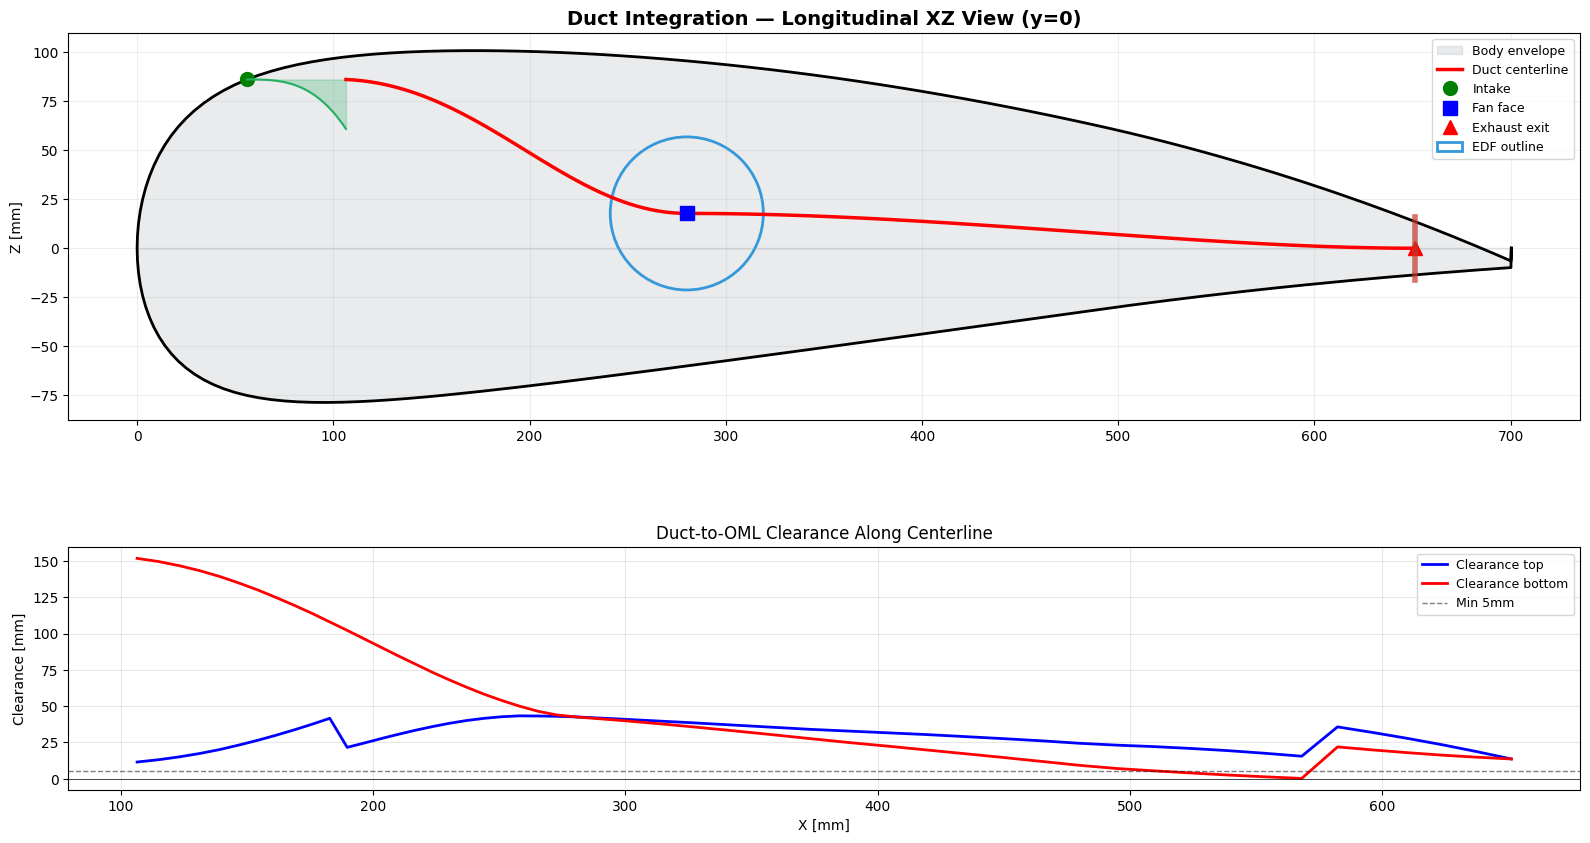

In [3]:
# Body airfoil outline
af = build_body_airfoil(tc=params.body_tc_root, camber=params.body_camber,
                        reflex=params.body_reflex, le_droop=params.body_le_droop,
                        n_pts=100)
af_x = af.coordinates[:, 0] * bc * 1000
af_z = af.coordinates[:, 1] * bc * 1000

# Duct centerline
centerline = compute_duct_centerline(placement, n_pts=100)

# Clearance envelope from validation results
clr_x = [r.x_mm for r in clr_results]
clr_top = [r.clearance_top_mm for r in clr_results]
clr_bot = [r.clearance_bot_mm for r in clr_results]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), height_ratios=[3, 1])

# --- Top: XZ integration view ---
ax1.fill_between(af_x, af_z, alpha=0.1, color='#2c3e50', label='Body envelope')
ax1.plot(af_x, af_z, 'k-', linewidth=2)

# Duct centerline
ax1.plot(centerline[:, 0]*1000, centerline[:, 2]*1000,
         'r-', linewidth=2.5, label='Duct centerline')

# Key stations
ax1.plot(placement.intake_x*1000, placement.intake_z*1000,
         'go', markersize=10, label='Intake')
ax1.plot(placement.fan_x*1000, placement.fan_z*1000,
         'bs', markersize=10, label='Fan face')
ax1.plot(placement.exhaust_x*1000, placement.exhaust_z*1000,
         'r^', markersize=10, label='Exhaust exit')

# EDF circle
fan_r = placement.duct_od / 2 * 1000
fan_circle = Circle((placement.fan_x*1000, placement.fan_z*1000), fan_r,
                     fill=False, color='#3498db', linewidth=2, label='EDF outline')
ax1.add_patch(fan_circle)

# Intake scoop
ramp_x = np.linspace(0, placement.intake_length*1000, 30)
ramp_depth = placement.intake_depth*1000 * (ramp_x / (placement.intake_length*1000))**3
ix_mm = placement.intake_x * 1000
iz_mm = placement.intake_z * 1000
ax1.fill_between(ix_mm + ramp_x, iz_mm, iz_mm - ramp_depth,
                 alpha=0.25, color='#27ae60')
ax1.plot(ix_mm + ramp_x, iz_mm - ramp_depth, '-', color='#27ae60', linewidth=1.5)

# Exhaust slot
ex_mm = placement.exhaust_x * 1000
ez_mm = placement.exhaust_z * 1000
eh_mm = placement.exhaust_height / 2 * 1000
ax1.plot([ex_mm, ex_mm], [ez_mm-eh_mm, ez_mm+eh_mm],
         '-', color='#c0392b', linewidth=4, alpha=0.7)

ax1.set_ylabel('Z [mm]')
ax1.set_title('Duct Integration — Longitudinal XZ View (y=0)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.2)

# --- Bottom: Clearance diagram ---
ax2.plot(clr_x, clr_top, 'b-', linewidth=2, label='Clearance top')
ax2.plot(clr_x, clr_bot, 'r-', linewidth=2, label='Clearance bottom')
ax2.axhline(5.0, color='k', linestyle='--', linewidth=1, alpha=0.5, label='Min 5mm')
ax2.axhline(0, color='k', linewidth=0.5)
ax2.fill_between(clr_x, clr_top, 0, where=[t < 0 for t in clr_top],
                 alpha=0.3, color='red')
ax2.fill_between(clr_x, clr_bot, 0, where=[b < 0 for b in clr_bot],
                 alpha=0.3, color='red')
ax2.set_xlabel('X [mm]')
ax2.set_ylabel('Clearance [mm]')
ax2.set_title('Duct-to-OML Clearance Along Centerline')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/integration_xz_clearance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Cross-Sections & Transverse Cuts

Cross-section shape evolution (intake → fan → exhaust) and transverse body-vs-duct fit at key stations.

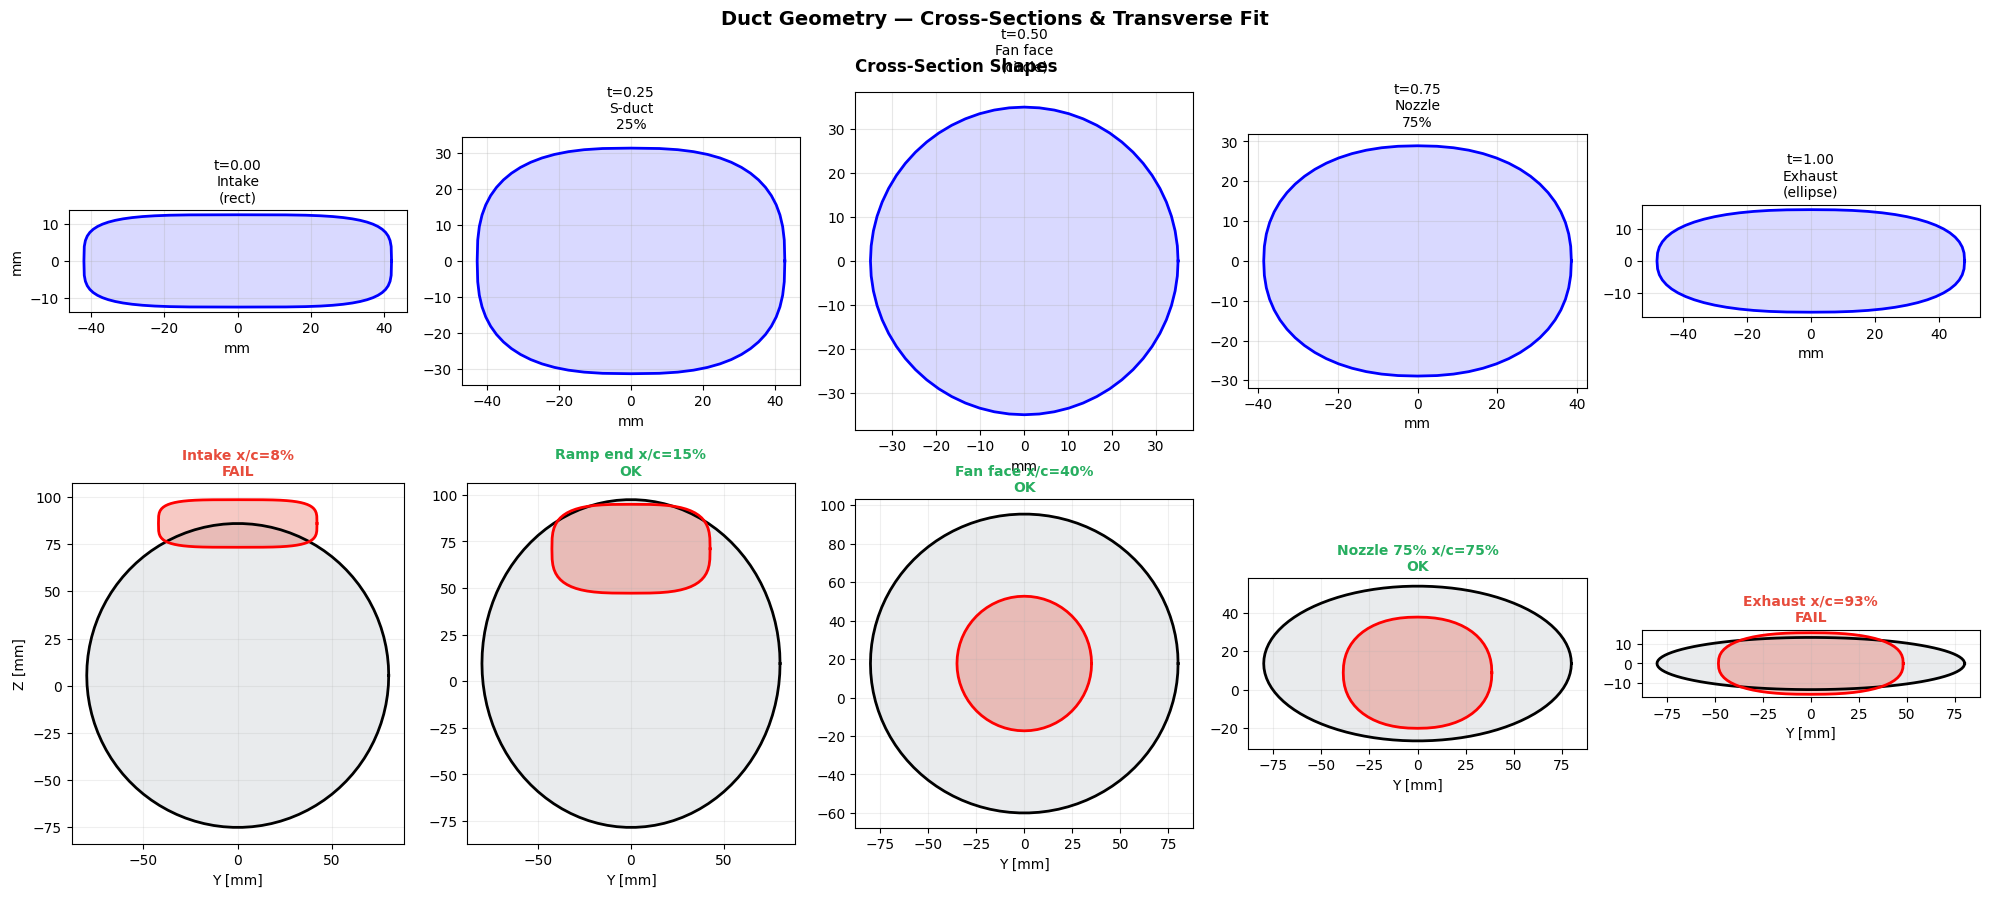

In [4]:
from src.propulsion.duct_geometry import _body_surface_z

fig, axes = plt.subplots(2, 5, figsize=(20, 9))

stations = [0.0, 0.25, 0.5, 0.75, 1.0]
names = ['Intake\n(rect)', 'S-duct\n25%', 'Fan face\n(circle)', 'Nozzle\n75%', 'Exhaust\n(ellipse)']

# Row 1: Cross-section shapes
for ax, t, name in zip(axes[0], stations, names):
    cs = duct_cross_section(t, placement, n_pts=64)
    cs_closed = np.vstack([cs, cs[0]])
    ax.plot(cs_closed[:, 0]*1000, cs_closed[:, 1]*1000, 'b-', linewidth=2)
    ax.fill(cs_closed[:, 0]*1000, cs_closed[:, 1]*1000, alpha=0.15, color='blue')
    ax.set_title(f't={t:.2f}\n{name}', fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('mm')
    if t == 0.0:
        ax.set_ylabel('mm')

# Row 2: Transverse body-vs-duct cuts
cs_stations = [
    (placement.intake_x_frac, 0.0, 'Intake'),
    ((placement.intake_x + placement.intake_length) / bc, 0.15, 'Ramp end'),
    (placement.fan_x_frac, 0.5, 'Fan face'),
    (0.75, 0.75, 'Nozzle 75%'),
    (placement.exhaust_x_frac, 1.0, 'Exhaust'),
]

cl = compute_duct_centerline(placement, n_pts=100)

for ax, (x_frac, t_cs, name) in zip(axes[1], cs_stations):
    z_up, z_cam, z_lo = _body_surface_z(x_frac, params.body_tc_root, params.body_camber,
                                         params.body_reflex, params.body_le_droop)
    z_up_mm = z_up * bc * 1000
    z_lo_mm = z_lo * bc * 1000
    z_cam_mm = z_cam * bc * 1000
    body_hw_mm = params.body_halfwidth * 1000

    # Body cross-section (elliptical approximation)
    th_up = np.linspace(0, np.pi, 50)
    th_lo = np.linspace(np.pi, 2*np.pi, 50)
    b_up = z_up_mm - z_cam_mm
    b_lo = z_cam_mm - z_lo_mm
    y_body = np.concatenate([body_hw_mm * np.cos(th_up), body_hw_mm * np.cos(th_lo)])
    z_body = np.concatenate([z_cam_mm + b_up * np.sin(th_up),
                             z_cam_mm + b_lo * np.sin(th_lo)])
    ax.fill(y_body, z_body, alpha=0.1, color='#2c3e50')
    ax.plot(y_body, z_body, 'k-', linewidth=2)

    # Duct cross-section at centerline z
    cs = duct_cross_section(t_cs, placement, n_pts=64)
    cs_closed = np.vstack([cs, cs[0]])
    idx = int(t_cs * (len(cl) - 1))
    duct_cz = cl[idx, 2] * 1000
    ax.fill(cs_closed[:, 0]*1000, cs_closed[:, 1]*1000 + duct_cz,
            alpha=0.3, color='#e74c3c')
    ax.plot(cs_closed[:, 0]*1000, cs_closed[:, 1]*1000 + duct_cz,
            'r-', linewidth=2)

    # Check fit
    duct_top = duct_cz + cs[:, 1].max() * 1000
    duct_bot = duct_cz + cs[:, 1].min() * 1000
    ok = duct_top < z_up_mm and duct_bot > z_lo_mm
    color = '#27ae60' if ok else '#e74c3c'
    ax.set_title(f'{name} x/c={x_frac:.0%}\n{"OK" if ok else "FAIL"}',
                 fontsize=10, color=color, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_xlabel('Y [mm]')
    if ax == axes[1][0]:
        ax.set_ylabel('Z [mm]')

axes[0][2].set_title('Cross-Section Shapes', fontsize=12, fontweight='bold', loc='left', pad=15)
fig.suptitle('Duct Geometry — Cross-Sections & Transverse Fit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/integration_cross_sections.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Aerodynamic Performance

Duct pressure recovery, mass flow, and exit velocity at cruise and across the speed range.

  DUCT AERODYNAMIC PERFORMANCE
  Mass flow rate:       0.2007 kg/s
  Fan face velocity:    42.9 m/s

  Intake capture area:  82.6 cm²
  Fan face area:        38.5 cm²
  Exhaust exit area:    30.8 cm²
  Nozzle area ratio:    0.800

  Pressure recovery:
    Intake (NACA):      0.950
    S-duct:             0.977
    Nozzle:             0.980
    TOTAL:              0.909

  Exit velocity:        53.6 m/s
  Velocity ratio:       2.68
  S-duct offset/L:      0.393
  CD intake increment:  0.00044

  WARNINGS:
    - Intake area 21.2 cm² < required 82.6 cm² (mass flow deficit)


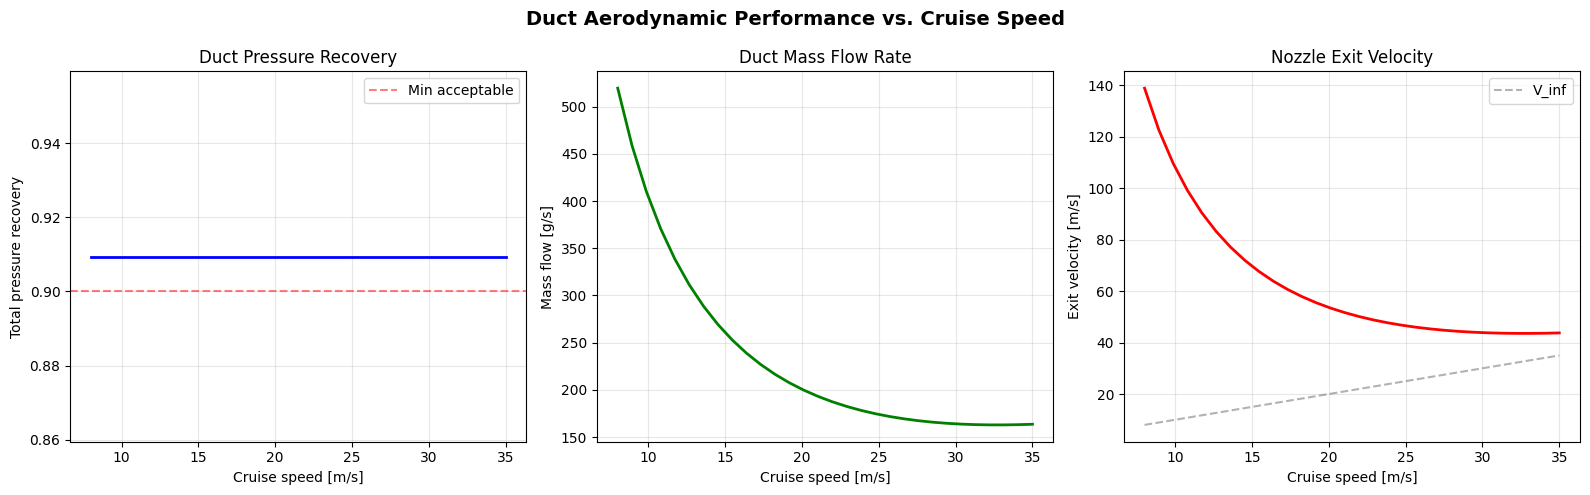

In [5]:
# Detailed summary at cruise speed
aero = compute_duct_aero(placement, EDF_70MM, params, velocity=20.0)
print_duct_aero_summary(aero)

# Performance vs. cruise speed
velocities = np.linspace(8, 35, 30)
pr_totals, mass_flows, exit_vels = [], [], []
for v in velocities:
    r = compute_duct_aero(placement, EDF_70MM, params, velocity=v)
    pr_totals.append(r.pr_total)
    mass_flows.append(r.mass_flow)
    exit_vels.append(r.exit_velocity)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

ax1.plot(velocities, pr_totals, 'b-', linewidth=2)
ax1.axhline(0.90, color='r', linestyle='--', alpha=0.5, label='Min acceptable')
ax1.set_xlabel('Cruise speed [m/s]')
ax1.set_ylabel('Total pressure recovery')
ax1.set_title('Duct Pressure Recovery')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(velocities, np.array(mass_flows)*1000, 'g-', linewidth=2)
ax2.set_xlabel('Cruise speed [m/s]')
ax2.set_ylabel('Mass flow [g/s]')
ax2.set_title('Duct Mass Flow Rate')
ax2.grid(True, alpha=0.3)

ax3.plot(velocities, exit_vels, 'r-', linewidth=2)
ax3.plot(velocities, velocities, 'k--', alpha=0.3, label='V_inf')
ax3.set_xlabel('Cruise speed [m/s]')
ax3.set_ylabel('Exit velocity [m/s]')
ax3.set_title('Nozzle Exit Velocity')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle('Duct Aerodynamic Performance vs. Cruise Speed',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/integration_aero_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 3D Visualization

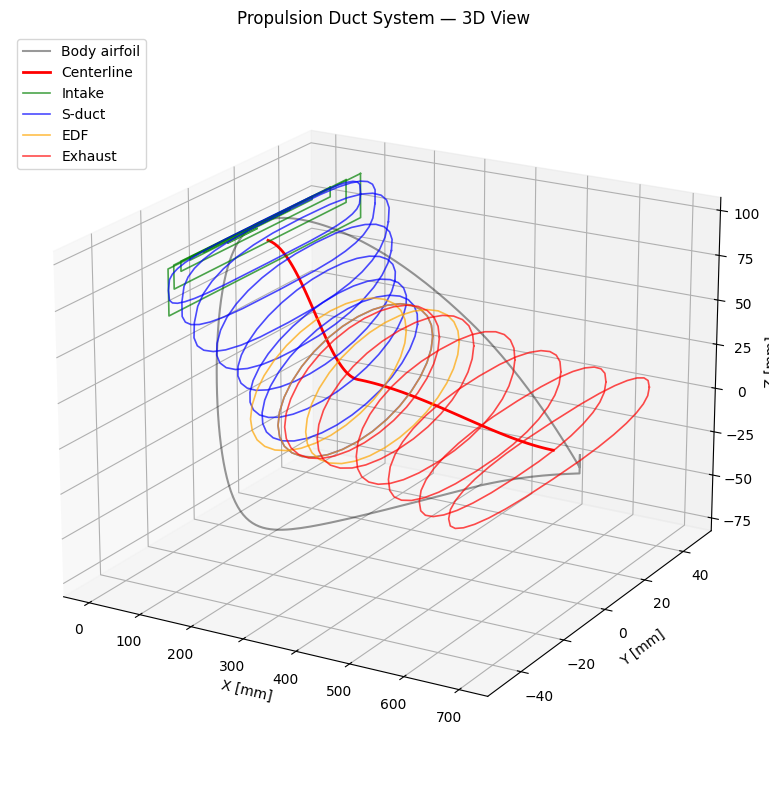

In [6]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Body airfoil outline at y=0
ax.plot(af.coordinates[:, 0] * bc * 1000,
        np.zeros(len(af.coordinates)),
        af.coordinates[:, 1] * bc * 1000,
        'k-', linewidth=1.5, alpha=0.4, label='Body airfoil')

# Duct centerline
ax.plot(centerline[:, 0]*1000, centerline[:, 1]*1000,
        centerline[:, 2]*1000, 'r-', linewidth=2, label='Centerline')

# Component sections
colors = {'Intake': 'green', 'S-duct': 'blue', 'EDF': 'orange', 'Exhaust': 'red'}
components = [
    ('Intake', build_intake_geometry(placement, params, n_profile=32, n_axial=6)),
    ('S-duct', build_sduct_geometry(placement, params, EDF_70MM, n_stations=8, n_profile=32)),
    ('EDF', build_edf_housing(placement, EDF_70MM, n_profile=32, n_axial=3)),
    ('Exhaust', build_exhaust_geometry(placement, params, EDF_70MM, n_stations=6, n_profile=32)),
]

for name, sections in components:
    c = colors[name]
    for i, sec in enumerate(sections):
        sec_closed = np.vstack([sec, sec[0]])
        label = name if i == 0 else None
        ax.plot(sec_closed[:, 0]*1000, sec_closed[:, 1]*1000,
                sec_closed[:, 2]*1000, '-', color=c, linewidth=1.2,
                alpha=0.7, label=label)

ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')
ax.set_zlabel('Z [mm]')
ax.set_title('Propulsion Duct System — 3D View')
ax.legend(loc='upper left')
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()

## 6. CAD Export (STL + STEP)

STL for quick visualization, STEP with boolean-cut intake/exhaust openings for FreeCAD.

The STEP compound contains 2 bodies:
- **Body 1**: OML with intake+exhaust openings cut out
- **Body 2**: Internal duct solid

Toggle visibility in FreeCAD to inspect each separately.

In [7]:
from src.visualization.export import export_aircraft_stl, export_aircraft_step_v3

# --- STL export ---
stl_path = '../output/neuron_v2_with_propulsion.stl'
n_tris = export_aircraft_stl(params, stl_path,
                              include_propulsion=True, edf=EDF_70MM)
print(f'STL: {n_tris} triangles -> {stl_path}')

# --- STEP export (v3 with boolean cuts) ---
step_path = '../output/cad_export/neuron_v2_with_propulsion.step'
result = export_aircraft_step_v3(params, step_path, edf=EDF_70MM)

print(f'\n--- STEP Export Summary ---')
print(f'  Compound:     {result["file_size_kb"]:.0f} KB  ({result["path"]})')
print(f'  OML only:     {result["oml_size_kb"]:.0f} KB  ({result["oml_path"]})')
print(f'  Duct only:    {result["duct_size_kb"]:.0f} KB  ({result["duct_path"]})')
print(f'  Mode:         {result["compound_mode"]}')
print(f'  Boolean cut:  {result["boolean_cut_ok"]}')
print(f'  Clearance:    {result["clearance_ok"]}')
print(f'  Valid:        {result["is_valid"]}')
print(f'  Volume:       {result["volume_mm3"]/1e6:.1f} cm3')

# Verify STEP file size
if result['file_size_kb'] < 300:
    print(f'\n  WARNING: STEP file seems small ({result["file_size_kb"]:.0f} KB < 300 KB)')

STL: 17030 triangles -> ../output/neuron_v2_with_propulsion.stl
[v3] 1/6  Building OML solid (v2 pipeline)...
[v3]      OML OK  (3733 KB, 12.6 cm3)
[v3] 2/6  Computing duct placement...
[v3] 3/6  Building internal duct solid...
[v3]      Duct OK (22 sections, 1705 KB)
[v3] 4/6  Validating duct clearance...
[v3] 5/6  Cutting intake/exhaust openings in OML...


d:\nEUROn_v2\notebooks\..\src\visualization\export.py:1209: UserWarning: Clearance violation at x/c=0.749: top=20.8mm bot=3.9mm
  warnings.warn(
d:\nEUROn_v2\notebooks\..\src\visualization\export.py:1209: UserWarning: Clearance violation at x/c=0.770: top=19.3mm bot=2.5mm
  warnings.warn(
d:\nEUROn_v2\notebooks\..\src\visualization\export.py:1209: UserWarning: Clearance violation at x/c=0.791: top=17.5mm bot=1.3mm
  warnings.warn(
d:\nEUROn_v2\notebooks\..\src\visualization\export.py:1209: UserWarning: Clearance violation at x/c=0.811: top=15.5mm bot=0.2mm
  warnings.warn(


[v3]      Intake cut OK
[v3]      Exhaust cut OK
[v3] 6/6  Assembling compound...
[v3] Done: 7740 KB, valid=False, cut=True, vol=2.1 cm3

--- STEP Export Summary ---
  Compound:     7740 KB  (../output/cad_export/neuron_v2_with_propulsion.step)
  OML only:     3733 KB  (../output/cad_export/neuron_v2_with_propulsion_oml_only.step)
  Duct only:    1705 KB  (../output/cad_export/neuron_v2_with_propulsion_duct_only.step)
  Mode:         boolean cut (intake+exhaust) + duct
  Boolean cut:  True
  Clearance:    False
  Valid:        False
  Volume:       2.1 cm3
